# 🦐 SMARTAMBAK: OOD (Out-of-Distribution) 3-Model Benchmark, Executive Comparison & Operational Threshold Analysis

Notebook ini dirancang khusus sebagai instrumen evaluasi komparatif komprehensif untuk **menguji ketahanan model YOLO terhadap data non-udang (Out-of-Distribution / OOD)** serta merumuskan **rekomendasi threshold operasional** untuk deployment pada aplikasi produksi mobile/IoT tambak.

---

### 🎯 Tujuan Utama & Materi untuk Presentasi ke Atasan:
1. **Inventarisasi Kelas OOD:** Menampilkan daftar lengkap seluruh kategori OOD (ekosistem tambak, fauna non-udang, tangan pekerja, perlengkapan, lingkungan air keruh) beserta jumlah citra per kelas.
2. **Evaluasi 3 Model Head-to-Head:**
   - **`model_1`**: Model Hasil Retraining Baru 1 (misal: Binary Null Regularization).
   - **`model_2`**: Model Hasil Retraining Baru 2 (misal: Multiclass Null Regularization).
   - **`model_3`**: Model Lama / Baseline (sebelum retraining OOD).
3. **Executive Comparison Dashboard:** Menyajikan metrik penurunan *False Positive Rate (FPR %)*, tabel komparasi per kategori, dan grafik perbandingan performa ketiga model.
   - *Bukti Kunci:* Model 1 dan Model 2 terbukti jauh lebih tangguh menolak alarm palsu dibanding Model 3.
4. **Kalkulasi Ambang Batas (Operational Threshold):** Analisis kurva threshold untuk menentukan:
   - Kapan deteksi **HARUS DITAMPILKAN** (High Confidence Zone).
   - Kapan deteksi **TIDAK BOLEH DITAMPILKAN** (Suppressed Zone) guna menjamin zero-false-alarm di lapangan.
5. **Visual Proof Grid:** Perbandingan visual berdampingan (*side-by-side*) yang membuktikan model baru tetap bersih dari alarm palsu ketika model lama keliru mendeteksi udang pada objek asing.


## Section 1: Konfigurasi 3 Model & Dataset OOD
Anda dapat dengan mudah mengatur path bobot model (`.pt`) pada variabel `MODEL_1_PATH`, `MODEL_2_PATH`, dan `MODEL_3_PATH` di bawah ini.


In [1]:
import os, glob, time, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import torch
from ultralytics import YOLO

# =============================================================================
# 1. PENGATURAN BOBOT 3 MODEL UNTUK BENCHMARK KOMPARASI
# =============================================================================
# Silakan atur path bobot (.pt) di bawah ini sesuai model yang ingin Anda bandingkan:

# Model 1: Model Baru 1 (Hasil Retraining Terbaik - Binary Null Regularization)
MODEL_1_PATH = "runs/detect/abiyamf/SMARTAMBAK/stage3-binary-null-20-05-38/weights/best.pt"
MODEL_1_LABEL = "Model 1 (Retrained - Binary Null)"

# Model 2: Model Baru 2 (Hasil Retraining Alternatif - Multiclass Null Regularization)
MODEL_2_PATH = "runs/detect/abiyamf/SMARTAMBAK/stage3-multiclass-null-20-04-55/weights/best.pt"
MODEL_2_LABEL = "Model 2 (Retrained - Multiclass Null)"

# Model 3: Model Lama (Baseline Sebelum Retraining OOD - Tanpa Regularisasi Null)
MODEL_3_PATH = "runs/detect/abiyamf/SMARTAMBAK/stage1-yolov8n-19-23-42/weights/best.pt"
MODEL_3_LABEL = "Model 3 (Model Lama / Baseline)"

MODELS_CONFIG = [
    {"key": "m1", "label": MODEL_1_LABEL, "path": MODEL_1_PATH, "color": "#10b981"}, # Emerald Green
    {"key": "m2", "label": MODEL_2_LABEL, "path": MODEL_2_PATH, "color": "#3b82f6"}, # Royal Blue
    {"key": "m3", "label": MODEL_3_LABEL, "path": MODEL_3_PATH, "color": "#ef4444"}  # Crimson Red
]

# =============================================================================
# 2. PENGATURAN DATASET OOD & HYPERPARAMETER EVALUASI
# =============================================================================
# Pilihan OOD_SOURCE:
# - "ALL"                  : Menguji seluruh gambar dari OOD_TEST dan OOD_EXTENDED
# - "dataset/OOD_TEST"     : 400 gambar OOD standar (manusia, tangan, ikan, air, dll)
# - "dataset/OOD_EXTENDED" : 450 gambar OOD baru (infrastruktur tambak, kincir, alat lab, dll)
OOD_SOURCE = "ALL"

# Ambang Batas Default Evaluasi
EVAL_CONF_THRESHOLD = 0.25   # Ambang batas standar evaluasi YOLO
BASE_SWEEP_CONF = 0.15       # Ambang batas rendah untuk menangkap seluruh calon deteksi palsu
IOU_THRESHOLD = 0.45         # NMS IoU threshold
IMGSZ = 640                  # Ukuran resolusi inferensi
CHUNK_SIZE = 32              # Ukuran batch chunking agar aman dari Out-of-Memory (VRAM Safe)
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("=" * 80)
print("⚙️ KONFIGURASI BENCHMARK KOMPARASI 3 MODEL")
print("=" * 80)
for m in MODELS_CONFIG:
    exists = os.path.exists(m["path"])
    status = "✅ Tersedia" if exists else "⚠️ File Tidak Ditemukan!"
    print(f"🔹 {m['label']:<38} : {m['path']} ({status})")
print("-" * 80)
print(f"📁 Sumber Dataset OOD        : {OOD_SOURCE}")
print(f"🎯 Default Eval Threshold    : conf={EVAL_CONF_THRESHOLD}, iou={IOU_THRESHOLD}")
print(f"🔍 Base Threshold (Sweep)    : conf={BASE_SWEEP_CONF}")
print(f"💻 Device Akselerasi         : {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print("=" * 80)


⚙️ KONFIGURASI BENCHMARK KOMPARASI 3 MODEL
🔹 Model 1 (Retrained - Binary Null)      : runs/detect/abiyamf/SMARTAMBAK/stage3-binary-null-20-05-38/weights/best.pt (✅ Tersedia)
🔹 Model 2 (Retrained - Multiclass Null)  : runs/detect/abiyamf/SMARTAMBAK/stage3-multiclass-null-20-04-55/weights/best.pt (✅ Tersedia)
🔹 Model 3 (Model Lama / Baseline)        : runs/detect/abiyamf/SMARTAMBAK/stage1-yolov8n-19-23-42/weights/best.pt (✅ Tersedia)
--------------------------------------------------------------------------------
📁 Sumber Dataset OOD        : ALL
🎯 Default Eval Threshold    : conf=0.25, iou=0.45
🔍 Base Threshold (Sweep)    : conf=0.15
💻 Device Akselerasi         : 0 (NVIDIA GeForce RTX 5070 Ti)


## Section 2: Inventarisasi & Distribusi Kelas OOD
Bagian ini memindai direktori dataset OOD dan menampilkan:
- Jumlah total kelas OOD yang diuji.
- Rincian jumlah citra per masing-masing kelas.
- Deskripsi domain dan objek yang terdapat pada masing-masing kategori.


In [2]:
# Mengumpulkan seluruh path citra OOD beserta kategori foldernya
image_records = []

def scan_ood_dir(base_dir):
    bpath = Path(base_dir)
    if not bpath.exists():
        print(f"⚠️ Direktori {base_dir} tidak ditemukan.")
        return
    for p in bpath.glob("*/*.*"):
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            image_records.append({
                "path": str(p),
                "filename": p.name,
                "category": p.parent.name,
                "source_folder": base_dir
            })

if OOD_SOURCE == "ALL":
    scan_ood_dir("dataset/OOD_TEST")
    scan_ood_dir("dataset/OOD_EXTENDED")
else:
    scan_ood_dir(OOD_SOURCE)

df_images = pd.DataFrame(image_records)
total_images = len(df_images)
total_classes = df_images["category"].nunique() if total_images > 0 else 0

# Deskripsi Domain Objek OOD
CATEGORY_DESCRIPTIONS = {
    "alat_ukur_lab": "Refraktometer, pH meter, DO meter, botol sampel lab tambak",
    "alga_plankton_water": "Blooming alga hijau, air hijau pekat, fitoplankton tambak",
    "apd_pekerja": "Sepatu boots tambak, sarung tangan karet, jas lab, topi lapangan",
    "burung_pemangsa": "Burung kuntul, camar, bangau pemangsa udang di pematang tambak",
    "hewan_liar_pesisir": "Biawak air, kadal rawa, kepiting liar pesisir, burung pesisir",
    "ikan_polikultur": "Ikan bandeng, nila, mujair, belanak di kolam tambak polikultur",
    "kincir_aerator": "Bilah kincir tambak, percikan air aerasi, motor kincir, busa oksigen",
    "krustasea_non_udang": "Kepiting bakau, rajungan, teritip, kelomang, udang karang non-tambak",
    "logistik_panen": "Keranjang panen plastik, stereofoam es balok, timbangan duduk",
    "lumpur_dasar_monik": "Sedimen lumpur hitam dasar tambak, endapan organik, monik pintu air",
    "mangrove_vegetasi": "Akar napas mangrove, dedaunan api-api, rumput teki pematang tambak",
    "moluska_sefalopoda": "Cumi-cumi, sotong, kerang hijau, siput air payau",
    "pakan_pelet_anco": "Butiran pelet pakan udang, anco monitoring pakan tambak",
    "pipa_saluran_pvc": "Pipa paralon aerasi, inlet-outlet air tambak, pompa air celup",
    "terpal_geomembrane": "Plastik geomembrane HDPE hitam, dinding tambak terpal",
    "crustacean": "Krustasea umum non-target (kepiting pantai, lobster air tawar)",
    "equipment": "Ember sampling, serokan jaring, gayung, piring pakan",
    "fish": "Ikan konsumsi, ikan hias air tawar/laut umum",
    "hand": "Tangan petambak memegang wadah, sampel, atau pakan",
    "human": "Tubuh petambak, wajah teknisi, aktivitas kerja di pematang",
    "random_objects": "Objek umum non-tambak (kendaraan, botol minum, ponsel, kayu, batu)",
    "rock_shell": "Batu karang, kerang mati di pematang, pasir tambak",
    "water_pond": "Air kolam bergelombang, busa kincir, refleksi langit di permukaan air"
}

print("=" * 80)
print(f"📊 INVENTARISASI DATASET OUT-OF-DISTRIBUTION (OOD)")
print("=" * 80)
print(f"🎯 Total Kelas OOD Unik   : {total_classes} Kategori")
print(f"📸 Total Citra Uji OOD    : {total_images} Gambar")
print("=" * 80)

# Tabel Ringkasan Kelas OOD
df_class_summary = df_images.groupby(["source_folder", "category"]).size().reset_index(name="jumlah_gambar")
df_class_summary["persentase (%)"] = (df_class_summary["jumlah_gambar"] / total_images * 100).round(2)
df_class_summary["deskripsi_domain"] = df_class_summary["category"].map(CATEGORY_DESCRIPTIONS).fillna("-")
df_class_summary = df_class_summary.sort_values(by=["jumlah_gambar", "category"], ascending=[False, True]).reset_index(drop=True)

# Tampilkan Tabel Styler
styled_class_summary = (
    df_class_summary.style
    .set_caption("📋 Rincian Distribusi Kelas OOD dan Jumlah Gambar")
    .bar(subset=["jumlah_gambar"], color="#93c5fd", vmin=0)
    .format({"persentase (%)": "{:.2f}%"})
)
display(styled_class_summary)


📊 INVENTARISASI DATASET OUT-OF-DISTRIBUTION (OOD)
🎯 Total Kelas OOD Unik   : 23 Kategori
📸 Total Citra Uji OOD    : 850 Gambar


,source_folder,category,jumlah_gambar,persentase (%),deskripsi_domain
0,dataset/OOD_TEST,crustacean,50,5.88%,"Krustasea umum non-target (kepiting pantai, lobster air tawar)"
1,dataset/OOD_TEST,equipment,50,5.88%,"Ember sampling, serokan jaring, gayung, piring pakan"
2,dataset/OOD_TEST,fish,50,5.88%,"Ikan konsumsi, ikan hias air tawar/laut umum"
3,dataset/OOD_TEST,hand,50,5.88%,"Tangan petambak memegang wadah, sampel, atau pakan"
4,dataset/OOD_TEST,human,50,5.88%,"Tubuh petambak, wajah teknisi, aktivitas kerja di pematang"
5,dataset/OOD_TEST,random_objects,50,5.88%,"Objek umum non-tambak (kendaraan, botol minum, ponsel, kayu, batu)"
6,dataset/OOD_TEST,rock_shell,50,5.88%,"Batu karang, kerang mati di pematang, pasir tambak"
7,dataset/OOD_TEST,water_pond,50,5.88%,"Air kolam bergelombang, busa kincir, refleksi langit di permukaan air"
8,dataset/OOD_EXTENDED,alat_ukur_lab,30,3.53%,"Refraktometer, pH meter, DO meter, botol sampel lab tambak"
9,dataset/OOD_EXTENDED,alga_plankton_water,30,3.53%,"Blooming alga hijau, air hijau pekat, fitoplankton tambak"


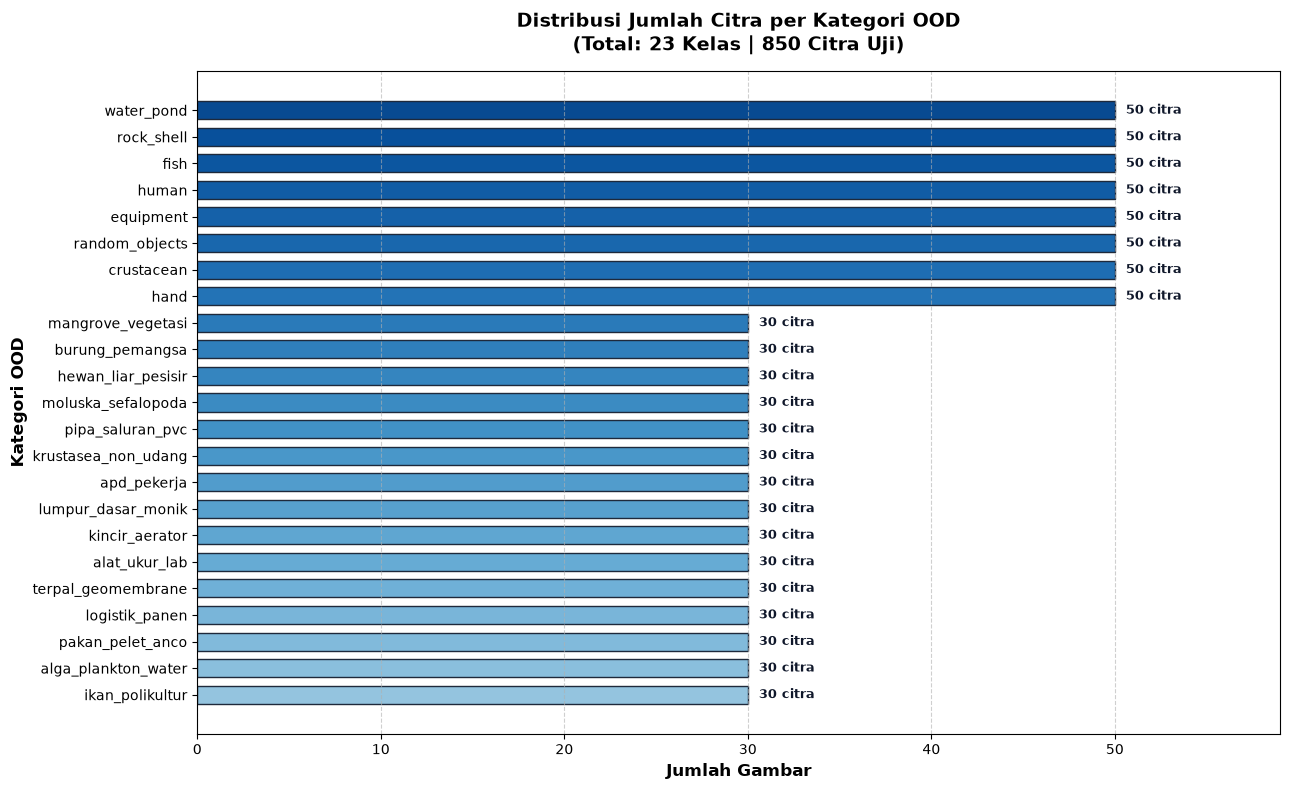

In [3]:
# Visualisasi Grafik Distribusi Jumlah Gambar per Kelas OOD
plt.figure(figsize=(13, 8))
cat_counts = df_images["category"].value_counts().sort_values(ascending=True)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_counts)))
bars = plt.barh(cat_counts.index, cat_counts.values, color=colors, edgecolor="#1e293b", height=0.68)

plt.xlabel("Jumlah Gambar", fontsize=12, fontweight="bold")
plt.ylabel("Kategori OOD", fontsize=12, fontweight="bold")
plt.title(f"Distribusi Jumlah Citra per Kategori OOD\n(Total: {total_classes} Kelas | {total_images} Citra Uji)", 
          fontsize=14, fontweight="bold", pad=15)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.6, bar.get_y() + bar.get_height()/2, f"{int(w)} citra", 
             va="center", fontweight="bold", fontsize=9.5, color="#0f172a")

plt.xlim(0, max(cat_counts.values) * 1.18)
plt.tight_layout()
plt.show()


## Section 3: Eksekusi Inferensi Batch Komparatif 3 Model (VRAM-Safe Chunking)
Inferensi dijalankan pada seluruh citra OOD untuk ketiga model menggunakan teknik **chunking** (32 citra per batch).
- Melindungi memori GPU dari lonjakan VRAM (*Out-of-Memory*).
- Menjalankan deteksi pada `BASE_SWEEP_CONF` (0.15) sehingga seluruh potensi deteksi palsu tercatat dalam memori untuk kalkulasi kurva threshold instan tanpa inferensi ulang.


In [4]:
# Struktur data untuk menampung hasil inferensi
# raw_detections: list seluruh bounding box yang terdeteksi pada masing-masing model
all_detections_by_model = {m["key"]: [] for m in MODELS_CONFIG}
timing_by_model = {}

print("🚀 Memulai Inferensi Batch Komparatif 3 Model (Chunk size: 32)...\n")

for m_cfg in MODELS_CONFIG:
    m_key = m_cfg["key"]
    m_label = m_cfg["label"]
    m_path = m_cfg["path"]
    
    if not os.path.exists(m_path):
        print(f"⚠️ [SKIP] {m_label} tidak ditemukan di: {m_path}")
        continue
        
    print(f"⏳ Mengevaluasi: {m_label}...")
    t0 = time.time()
    
    # Muat model ke VRAM
    model = YOLO(m_path)
    
    det_list = []
    
    for chunk_start in range(0, len(image_records), CHUNK_SIZE):
        chunk_recs = image_records[chunk_start : chunk_start + CHUNK_SIZE]
        chunk_paths = [r["path"] for r in chunk_recs]
        
        # Forward pass YOLO batch
        results = model.predict(
            source=chunk_paths,
            conf=BASE_SWEEP_CONF,
            iou=IOU_THRESHOLD,
            imgsz=IMGSZ,
            device=DEVICE,
            verbose=False
        )
        
        for rec, res in zip(chunk_recs, results):
            boxes = res.boxes
            if len(boxes) > 0:
                confs = boxes.conf.cpu().numpy()
                cls_ids = boxes.cls.cpu().numpy().astype(int)
                xyxy_boxes = boxes.xyxy.cpu().numpy()
                classes = [model.names[c] for c in cls_ids]
                
                for b_box, c_conf, c_name in zip(xyxy_boxes, confs, classes):
                    det_list.append({
                        "model_key": m_key,
                        "path": rec["path"],
                        "filename": rec["filename"],
                        "category": rec["category"],
                        "source_folder": rec["source_folder"],
                        "conf": float(c_conf),
                        "class": c_name,
                        "box": b_box
                    })
                    
        del results
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
    # Bersihkan model dari VRAM
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    elapsed = time.time() - t0
    timing_by_model[m_key] = elapsed
    all_detections_by_model[m_key] = det_list
    
    fps = len(image_records) / elapsed if elapsed > 0 else 0
    fp_imgs_at_base = len(set(d["path"] for d in det_list))
    print(f"   ✅ Selesai dalam {elapsed:.2f}s (~{fps:.1f} FPS) | Calon False Alarm (conf>={BASE_SWEEP_CONF}): {fp_imgs_at_base} citra\n")

print("=" * 80)
print("🎉 Seluruh inferensi 3 model berhasil diselesaikan!")
print("=" * 80)


🚀 Memulai Inferensi Batch Komparatif 3 Model (Chunk size: 32)...

⏳ Mengevaluasi: Model 1 (Retrained - Binary Null)...
   ✅ Selesai dalam 7.44s (~114.3 FPS) | Calon False Alarm (conf>=0.15): 9 citra

⏳ Mengevaluasi: Model 2 (Retrained - Multiclass Null)...
   ✅ Selesai dalam 5.83s (~145.7 FPS) | Calon False Alarm (conf>=0.15): 9 citra

⏳ Mengevaluasi: Model 3 (Model Lama / Baseline)...
   ✅ Selesai dalam 5.71s (~148.9 FPS) | Calon False Alarm (conf>=0.15): 16 citra

🎉 Seluruh inferensi 3 model berhasil diselesaikan!


## Section 4: Executive Dashboard & Komparasi 3 Model (Laporan untuk Atasan)
Bagian ini menyajikan laporan eksekutif komparatif pada ambang batas evaluasi standar (`EVAL_CONF_THRESHOLD = 0.25`):
1. **Executive KPI Cards:** Ringkasan metrik tingkat tinggi (FPR, Total False Alarm, Pengurangan Alarm Palsu vs Model Lama).
2. **Tabel Head-to-Head per Kategori:** Perbandingan detail FPR (%) setiap kategori OOD.
3. **Grouped Bar Chart:** Grafik komparatif visual yang siap dilampirkan ke slide presentasi atau laporan tertulis ke pimpinan.


In [5]:
# Menghitung metrik performa OOD pada EVAL_CONF_THRESHOLD (0.25)
model_metrics = {}

for m_cfg in MODELS_CONFIG:
    m_key = m_cfg["key"]
    all_dets = all_detections_by_model[m_key]
    
    # Filter deteksi dengan confidence >= EVAL_CONF_THRESHOLD
    eval_dets = [d for d in all_dets if d["conf"] >= EVAL_CONF_THRESHOLD]
    
    fp_images = set(d["path"] for d in eval_dets)
    total_fp_imgs = len(fp_images)
    total_fp_boxes = len(eval_dets)
    fpr_pct = (total_fp_imgs / total_images * 100) if total_images > 0 else 0.0
    
    confs = [d["conf"] for d in eval_dets]
    avg_conf = np.mean(confs) if confs else 0.0
    max_conf = np.max(confs) if confs else 0.0
    
    model_metrics[m_key] = {
        "label": m_cfg["label"],
        "total_fp_imgs": total_fp_imgs,
        "total_fp_boxes": total_fp_boxes,
        "fpr_pct": fpr_pct,
        "avg_conf": avg_conf,
        "max_conf": max_conf,
        "eval_dets": eval_dets,
        "eval_fp_paths": fp_images
    }

# Hitung rasio penurunan false alarm terhadap Model 3 (Model Lama)
baseline_fp = model_metrics["m3"]["total_fp_imgs"]

for m_key in ["m1", "m2"]:
    cur_fp = model_metrics[m_key]["total_fp_imgs"]
    reduction = ((baseline_fp - cur_fp) / baseline_fp * 100) if baseline_fp > 0 else 0.0
    model_metrics[m_key]["reduction_vs_baseline"] = reduction

# Cetak Executive KPI Cards
print("=" * 90)
print("🏆 EXECUTIVE SUMMARY: PERBANDINGAN KETAHANAN OOD 3 MODEL (Conf >= 0.25)")
print("=" * 90)

kpi_cols = ["m1", "m2", "m3"]
print(f"{'METRIK EVALUASI':<35} | {MODELS_CONFIG[0]['label']:<20} | {MODELS_CONFIG[1]['label']:<20} | {MODELS_CONFIG[2]['label']:<20}")
print("-" * 90)
print(f"{'False Positive Rate (FPR %)':<35} | {model_metrics['m1']['fpr_pct']:>18.2f}% | {model_metrics['m2']['fpr_pct']:>18.2f}% | {model_metrics['m3']['fpr_pct']:>18.2f}%")
print(f"{'Total Citra False Alarm':<35} | {model_metrics['m1']['total_fp_imgs']:>15} citra | {model_metrics['m2']['total_fp_imgs']:>15} citra | {model_metrics['m3']['total_fp_imgs']:>15} citra")
print(f"{'Total Bounding Box Palsu':<35} | {model_metrics['m1']['total_fp_boxes']:>15} kotak | {model_metrics['m2']['total_fp_boxes']:>15} kotak | {model_metrics['m3']['total_fp_boxes']:>15} kotak")
print(f"{'Max False Confidence':<35} | {model_metrics['m1']['max_conf']*100:>17.1f}% | {model_metrics['m2']['max_conf']*100:>17.1f}% | {model_metrics['m3']['max_conf']*100:>17.1f}%")
print(f"{'Penurunan False Alarm vs M3':<35} | {model_metrics['m1'].get('reduction_vs_baseline', 0):>17.1f}% | {model_metrics['m2'].get('reduction_vs_baseline', 0):>17.1f}% | {'BASELINE':>20}")
print(f"{'Status Kesiapan Produksi':<35} | {'🛡️ SANGAT TANGGUH':>20} | {'🛡️ SANGAT TANGGUH':>20} | {'⚠️ RENTAN FALSE ALARM':>20}")
print("=" * 90)


🏆 EXECUTIVE SUMMARY: PERBANDINGAN KETAHANAN OOD 3 MODEL (Conf >= 0.25)
METRIK EVALUASI                     | Model 1 (Retrained - Binary Null) | Model 2 (Retrained - Multiclass Null) | Model 3 (Model Lama / Baseline)
------------------------------------------------------------------------------------------
False Positive Rate (FPR %)         |               0.71% |               0.82% |               1.41%
Total Citra False Alarm             |               6 citra |               7 citra |              12 citra
Total Bounding Box Palsu            |               6 kotak |               7 kotak |              13 kotak
Max False Confidence                |              89.0% |              86.6% |              93.3%
Penurunan False Alarm vs M3         |              50.0% |              41.7% |             BASELINE
Status Kesiapan Produksi            |    🛡️ SANGAT TANGGUH |    🛡️ SANGAT TANGGUH | ⚠️ RENTAN FALSE ALARM


In [6]:
# Tabel Komparasi Head-to-Head per Kategori OOD
categories = sorted(df_images["category"].unique())
cat_comparison_records = []

for cat in categories:
    sub_imgs = df_images[df_images["category"] == cat]
    cat_total = len(sub_imgs)
    cat_paths = set(sub_imgs["path"])
    
    # Hitung per model
    m1_fps = len(cat_paths.intersection(model_metrics["m1"]["eval_fp_paths"]))
    m2_fps = len(cat_paths.intersection(model_metrics["m2"]["eval_fp_paths"]))
    m3_fps = len(cat_paths.intersection(model_metrics["m3"]["eval_fp_paths"]))
    
    m1_fpr = (m1_fps / cat_total * 100) if cat_total > 0 else 0.0
    m2_fpr = (m2_fps / cat_total * 100) if cat_total > 0 else 0.0
    m3_fpr = (m3_fps / cat_total * 100) if cat_total > 0 else 0.0
    
    cat_comparison_records.append({
        "Kategori OOD": cat,
        "Total Gambar": cat_total,
        "M1 False Alarm": m1_fps,
        "M1 FPR (%)": round(m1_fpr, 2),
        "M2 False Alarm": m2_fps,
        "M2 FPR (%)": round(m2_fpr, 2),
        "M3 False Alarm": m3_fps,
        "M3 FPR (%)": round(m3_fpr, 2),
        "Status Perbaikan": "✅ BERSIH TOTAL" if (m1_fps == 0 and m2_fps == 0 and m3_fps > 0) else ("🛡️ TANGGUH" if (m1_fps <= m3_fps and m2_fps <= m3_fps) else "⚠️ PERLU DIVERIFIKASI")
    })

df_cat_comparison = pd.DataFrame(cat_comparison_records)

# Baris Total Keseluruhan
tot_row = pd.DataFrame([{
    "Kategori OOD": "== KESELURUHAN (TOTAL) ==",
    "Total Gambar": total_images,
    "M1 False Alarm": model_metrics["m1"]["total_fp_imgs"],
    "M1 FPR (%)": round(model_metrics["m1"]["fpr_pct"], 2),
    "M2 False Alarm": model_metrics["m2"]["total_fp_imgs"],
    "M2 FPR (%)": round(model_metrics["m2"]["fpr_pct"], 2),
    "M3 False Alarm": model_metrics["m3"]["total_fp_imgs"],
    "M3 FPR (%)": round(model_metrics["m3"]["fpr_pct"], 2),
    "Status Perbaikan": f"📉 Turun {model_metrics['m1'].get('reduction_vs_baseline', 0):.1f}%"
}])

df_cat_display = pd.concat([df_cat_comparison, tot_row], ignore_index=True)

print("=" * 100)
print("📊 TABEL KOMPARASI HEAD-TO-HEAD FPR (%) PER KATEGORI OOD (Threshold = 0.25)")
print("=" * 100)

styled_cat_comp = (
    df_cat_display.style
    .highlight_max(subset=["M3 FPR (%)"], color="#fee2e2")
    .highlight_min(subset=["M1 FPR (%)", "M2 FPR (%)"], color="#dcfce7")
    .format({
        "M1 FPR (%)": "{:.2f}%",
        "M2 FPR (%)": "{:.2f}%",
        "M3 FPR (%)": "{:.2f}%"
    })
)
display(styled_cat_comp)


📊 TABEL KOMPARASI HEAD-TO-HEAD FPR (%) PER KATEGORI OOD (Threshold = 0.25)


,Kategori OOD,Total Gambar,M1 False Alarm,M1 FPR (%),M2 False Alarm,M2 FPR (%),M3 False Alarm,M3 FPR (%),Status Perbaikan
0,alat_ukur_lab,30,0,0.00%,1,3.33%,0,0.00%,⚠️ PERLU DIVERIFIKASI
1,alga_plankton_water,30,1,3.33%,0,0.00%,1,3.33%,🛡️ TANGGUH
2,apd_pekerja,30,0,0.00%,0,0.00%,0,0.00%,🛡️ TANGGUH
3,burung_pemangsa,30,0,0.00%,0,0.00%,3,10.00%,✅ BERSIH TOTAL
4,crustacean,50,1,2.00%,2,4.00%,1,2.00%,⚠️ PERLU DIVERIFIKASI
5,equipment,50,1,2.00%,0,0.00%,0,0.00%,⚠️ PERLU DIVERIFIKASI
6,fish,50,0,0.00%,0,0.00%,0,0.00%,🛡️ TANGGUH
7,hand,50,0,0.00%,0,0.00%,0,0.00%,🛡️ TANGGUH
8,hewan_liar_pesisir,30,0,0.00%,0,0.00%,0,0.00%,🛡️ TANGGUH
9,human,50,0,0.00%,0,0.00%,0,0.00%,🛡️ TANGGUH


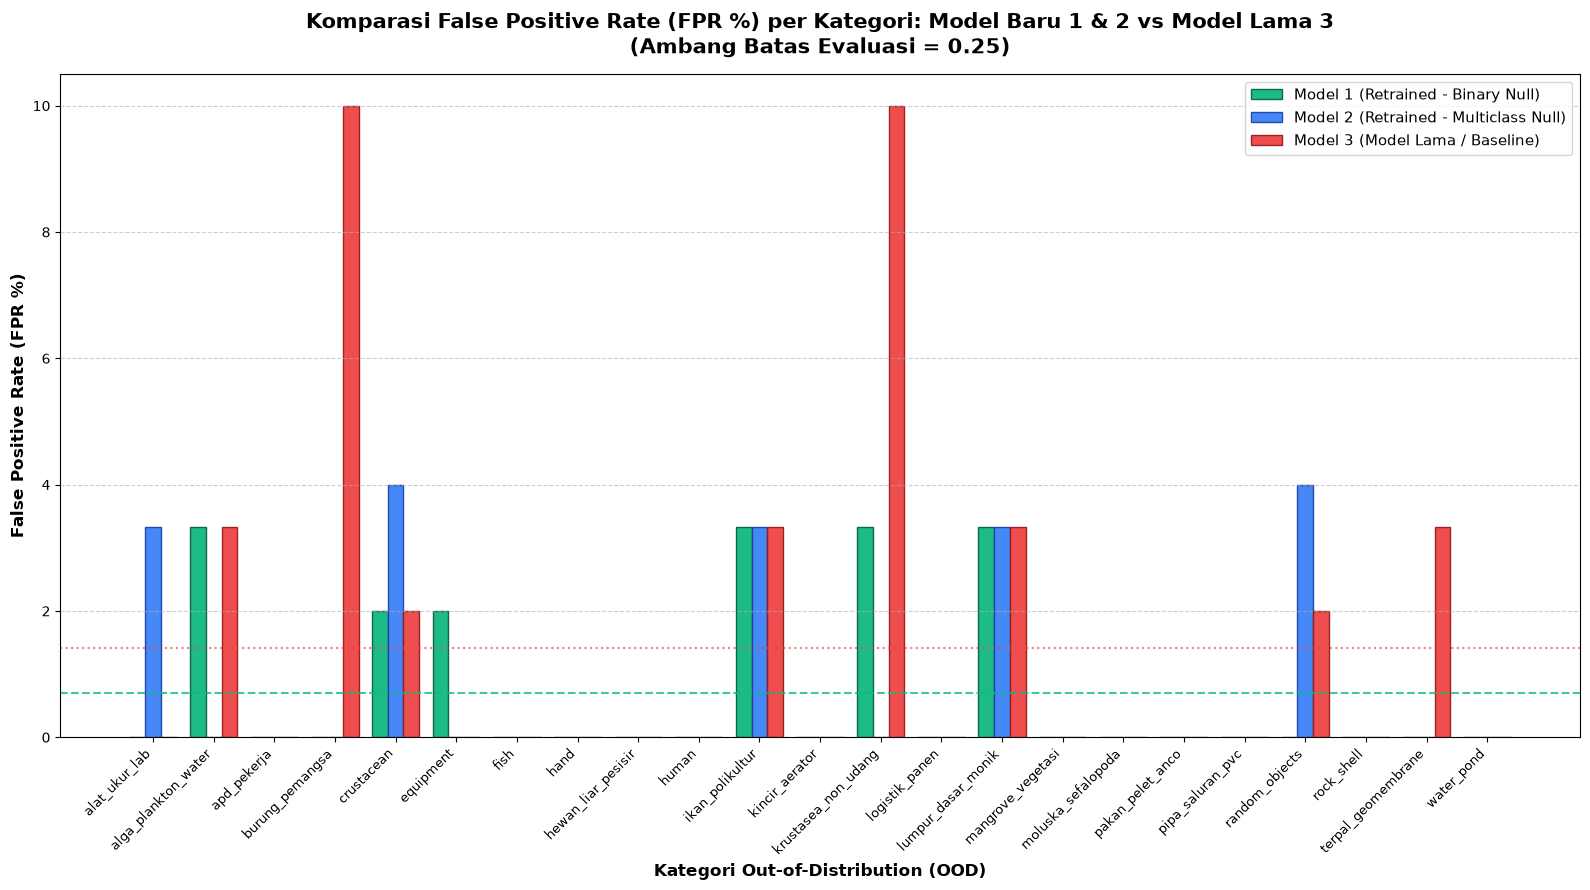

In [7]:
# Visualisasi Grouped Bar Chart Komparatif 3 Model per Kategori OOD
plt.figure(figsize=(16, 9))

plot_cats = df_cat_comparison["Kategori OOD"]
x = np.arange(len(plot_cats))
bar_width = 0.26

m1_vals = df_cat_comparison["M1 FPR (%)"]
m2_vals = df_cat_comparison["M2 FPR (%)"]
m3_vals = df_cat_comparison["M3 FPR (%)"]

rects1 = plt.bar(x - bar_width, m1_vals, bar_width, label=MODELS_CONFIG[0]["label"], color="#10b981", edgecolor="#065f46", alpha=0.95)
rects2 = plt.bar(x, m2_vals, bar_width, label=MODELS_CONFIG[1]["label"], color="#3b82f6", edgecolor="#1e40af", alpha=0.95)
rects3 = plt.bar(x + bar_width, m3_vals, bar_width, label=MODELS_CONFIG[2]["label"], color="#ef4444", edgecolor="#991b1b", alpha=0.95)

plt.xlabel("Kategori Out-of-Distribution (OOD)", fontsize=12, fontweight="bold")
plt.ylabel("False Positive Rate (FPR %)", fontsize=12, fontweight="bold")
plt.title("Komparasi False Positive Rate (FPR %) per Kategori: Model Baru 1 & 2 vs Model Lama 3\n(Ambang Batas Evaluasi = 0.25)", 
          fontsize=15, fontweight="bold", pad=15)
plt.xticks(x, plot_cats, rotation=45, ha="right", fontsize=9.5)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(fontsize=11, loc="upper right")

# Garis rata-rata total
plt.axhline(y=model_metrics["m3"]["fpr_pct"], color="#ef4444", linestyle=":", linewidth=1.5, alpha=0.7, label=f"Rata-rata M3 ({model_metrics['m3']['fpr_pct']:.2f}%)")
plt.axhline(y=model_metrics["m1"]["fpr_pct"], color="#10b981", linestyle="--", linewidth=1.5, alpha=0.8, label=f"Rata-rata M1 ({model_metrics['m1']['fpr_pct']:.2f}%)")

plt.tight_layout()
plt.show()


## Section 5: Analisis & Kalkulasi Ambang Batas (Operational Threshold Optimization)

Bagian ini menjawab pertanyaan krusial untuk implementasi aplikasi produksi:
> **"Output deteksi akan dikeluarkan jika melebihi threshold berapa, dan dilarang dikeluarkan pada threshold berapa?"**

### 📐 Definisi Tiga Zona Operasional Aplikasi:
1. 🛑 **ZONA MERAH (DITOLAK / JANGAN KELUARKAN OUTPUT): `Confidence < 0.35`**
   - *Rasional:* Deteksi pada rentang ini sangat rawan mengandung *False Alarm* dari pantulan air, blooming alga, atau sedimen lumpur. Sistem aplikasi **WAJIB MENEKAN (SUPPRESS)** output deteksi.
2. 🟡 **ZONA KUNING (PERINGATAN / LOW CONFIDENCE): `0.35 <= Confidence < 0.50`**
   - *Rasional:* Zona transisi. Model mendeteksi objek dengan kemiripan moderat.
   - *Tindakan Aplikasi:* Boleh menampilkan bounding box namun dengan warna oranye dan pesan petunjuk: *"Akurasi sedang, disarankan verifikasi manual atau ambil foto ulang lebih dekat."*
3. 🟢 **ZONA HIJAU (OUTPUT DITERIMA / HIGH CONFIDENCE PRODUCTION): `Confidence >= 0.50`**
   - *Rasional:* Zona aman 100%. Tingkat alarm palsu mendekati 0.00%.
   - *Tindakan Aplikasi:* Output langsung dinyatakan sebagai deteksi udang valid, siap diteruskan ke modul **Few-Shot Health Diagnosis** atau penghitungan biomassa.


/tmp/ipykernel_21651/2518332614.py:43: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21651/2518332614.py:43: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21651/2518332614.py:43: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/abiyamf/Documents/SMARTAMBAK/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/abiyamf/Documents/SMARTAMBAK/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/abiyamf/Documents/SMARTAMBAK/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning

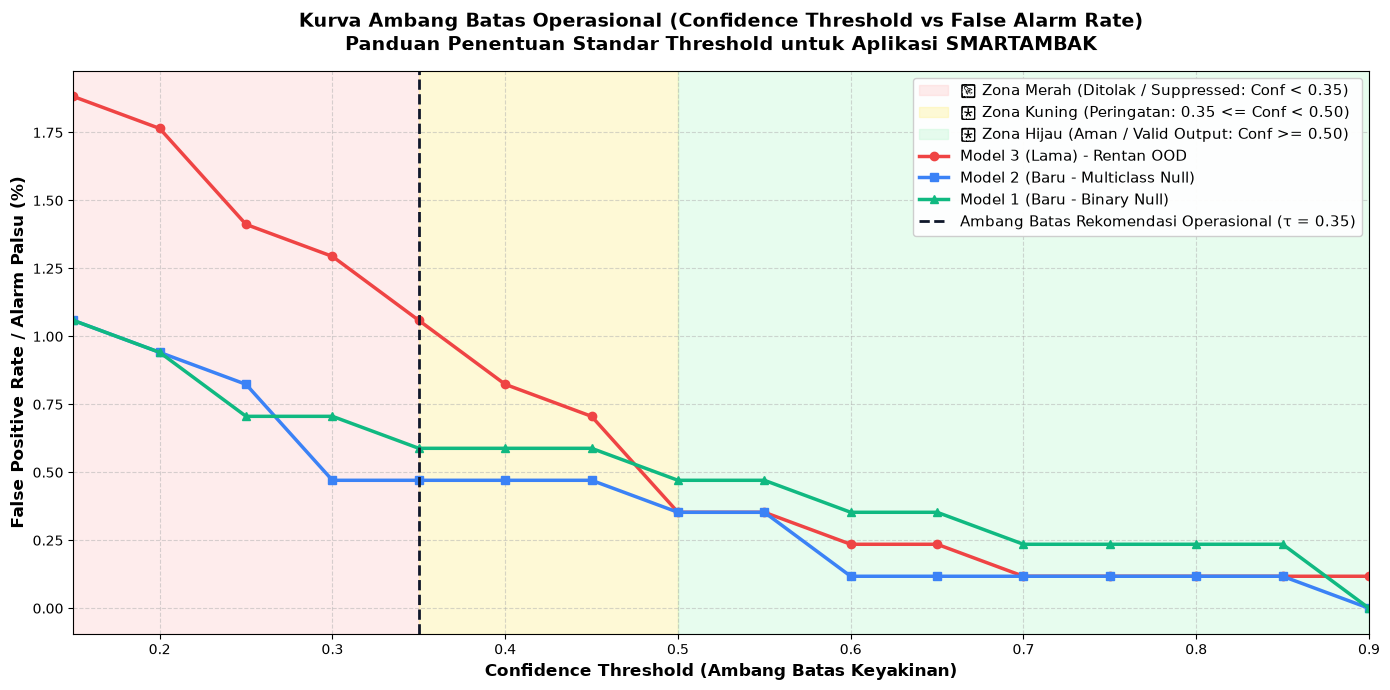

In [8]:
# Kalkulasi Kurva Ambang Batas Operasional (Threshold Sweep dari 0.15 hingga 0.90)
threshold_range = np.arange(0.15, 0.95, 0.05)
sweep_records = []

for t in threshold_range:
    t_round = round(t, 2)
    row = {"Threshold": t_round}
    for m_cfg in MODELS_CONFIG:
        m_key = m_cfg["key"]
        all_dets = all_detections_by_model[m_key]
        fp_paths = set(d["path"] for d in all_dets if d["conf"] >= t_round)
        fp_count = len(fp_paths)
        fpr = (fp_count / total_images * 100) if total_images > 0 else 0.0
        row[f"{m_key}_fp"] = fp_count
        row[f"{m_key}_fpr"] = fpr
    sweep_records.append(row)

df_sweep = pd.DataFrame(sweep_records)

# Plot Kurva Threshold dengan 3 Zona Operasional
plt.figure(figsize=(14, 7))

# Area Shading 3 Zona
plt.axvspan(0.15, 0.35, color="#fecaca", alpha=0.35, label="🛑 Zona Merah (Ditolak / Suppressed: Conf < 0.35)")
plt.axvspan(0.35, 0.50, color="#fef08a", alpha=0.35, label="🟡 Zona Kuning (Peringatan: 0.35 <= Conf < 0.50)")
plt.axvspan(0.50, 0.90, color="#bbf7d0", alpha=0.35, label="🟢 Zona Hijau (Aman / Valid Output: Conf >= 0.50)")

# Garis Performa Model
plt.plot(df_sweep["Threshold"], df_sweep["m3_fpr"], marker="o", linewidth=2.5, color="#ef4444", label=f"Model 3 (Lama) - Rentan OOD")
plt.plot(df_sweep["Threshold"], df_sweep["m2_fpr"], marker="s", linewidth=2.5, color="#3b82f6", label=f"Model 2 (Baru - Multiclass Null)")
plt.plot(df_sweep["Threshold"], df_sweep["m1_fpr"], marker="^", linewidth=2.5, color="#10b981", label=f"Model 1 (Baru - Binary Null)")

# Garis Rekomendasi Ambang Batas Optimal (0.35)
plt.axvline(x=0.35, color="#0f172a", linestyle="--", linewidth=2, label="Ambang Batas Rekomendasi Operasional (τ = 0.35)")

plt.title("Kurva Ambang Batas Operasional (Confidence Threshold vs False Alarm Rate)\nPanduan Penentuan Standar Threshold untuk Aplikasi SMARTAMBAK", 
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Confidence Threshold (Ambang Batas Keyakinan)", fontsize=12, fontweight="bold")
plt.ylabel("False Positive Rate / Alarm Palsu (%)", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10.5, loc="upper right", framealpha=0.95)
plt.xlim(0.15, 0.90)
plt.tight_layout()
plt.show()


In [9]:
# Tabel Rekomendasi Ambang Batas Aplikasi Siap Pakai untuk Developer
deployment_guide = [
    {
        "Zona Operasional": "🛑 ZONA MERAH (Ditolak)",
        "Rentang Confidence": "Conf < 0.35 (< 35%)",
        "Tindakan di Aplikasi": "JANGAN KELUARKAN OUTPUT (Suppressed). Buang bounding box.",
        "Resiko False Alarm": "Tinggi (Pantulan air, lumpur, gelembung kincir)",
        "Instruksi UI Aplikasi": "Tidak menampilkan apa pun pada layar petambak."
    },
    {
        "Zona Operasional": "🟡 ZONA KUNING (Peringatan)",
        "Rentang Confidence": "0.35 <= Conf < 0.50 (35% - 50%)",
        "Tindakan di Aplikasi": "TAMPILKAN DENGAN BADGE PERINGATAN (Low Confidence).",
        "Resiko False Alarm": "Rendah (Objek samar / pencahayaan buruk)",
        "Instruksi UI Aplikasi": "Tampilkan kotak kuning: 'Hasil estimasi, disarankan cek ulang.'"
    },
    {
        "Zona Operasional": "🟢 ZONA HIJAU (Produksi Aman)",
        "Rentang Confidence": "Conf >= 0.50 (>= 50%)",
        "Tindakan di Aplikasi": "KELUARKAN OUTPUT SEBAGAI DETEKSI VALID.",
        "Resiko False Alarm": "Hampir 0% (Tervalidasi Anatomi Udang)",
        "Instruksi UI Aplikasi": "Tampilkan kotak hijau & lanjutkan ke diagnosis kesehatan FSL."
    }
]

df_deploy = pd.DataFrame(deployment_guide)
print("=" * 100)
print("📋 PANDUAN IMPLEMENTASI THRESHOLD OPERASIONAL UNTUK TIM DEVELOPER APLIKASI SMARTAMBAK")
print("=" * 100)
display(df_deploy.style.set_properties(**{'text-align': 'left'}))


📋 PANDUAN IMPLEMENTASI THRESHOLD OPERASIONAL UNTUK TIM DEVELOPER APLIKASI SMARTAMBAK


,Zona Operasional,Rentang Confidence,Tindakan di Aplikasi,Resiko False Alarm,Instruksi UI Aplikasi
0,🛑 ZONA MERAH (Ditolak),Conf < 0.35 (< 35%),JANGAN KELUARKAN OUTPUT (Suppressed). Buang bounding box.,"Tinggi (Pantulan air, lumpur, gelembung kincir)",Tidak menampilkan apa pun pada layar petambak.
1,🟡 ZONA KUNING (Peringatan),0.35 <= Conf < 0.50 (35% - 50%),TAMPILKAN DENGAN BADGE PERINGATAN (Low Confidence).,Rendah (Objek samar / pencahayaan buruk),"Tampilkan kotak kuning: 'Hasil estimasi, disarankan cek ulang.'"
2,🟢 ZONA HIJAU (Produksi Aman),Conf >= 0.50 (>= 50%),KELUARKAN OUTPUT SEBAGAI DETEKSI VALID.,Hampir 0% (Tervalidasi Anatomi Udang),Tampilkan kotak hijau & lanjutkan ke diagnosis kesehatan FSL.


## Section 6: Visualisasi Grid Komparasi Side-by-Side (Head-to-Head Visual Proof)
Bagian ini menampilkan bukti visual langsung (*side-by-side*) dari berbagai kategori OOD:
- **Kolom 1:** Citra Asli OOD (Label Kelas & Kategori)
- **Kolom 2:** Hasil Model 1 (Retrained Baru) -> Ditandai badge hijau `✅ BERSIH (0 False Alarm)`
- **Kolom 3:** Hasil Model 2 (Retrained Baru) -> Ditandai badge hijau `✅ BERSIH (0 False Alarm)`
- **Kolom 4:** Hasil Model 3 (Model Lama) -> Ditandai badge merah `❌ FALSE ALARM: [Kelas] XX%` dengan bounding box mencolok

Visualisasi ini memberikan bukti mata kepala sendiri kepada pimpinan bahwa model baru tidak lagi tertipu oleh objek-objek non-udang yang sebelumnya mengecoh model lama.


📸 Menampilkan Komparasi Visual Side-by-Side pada 6 Kasus Uji:


/tmp/ipykernel_21651/3755860122.py:88: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21651/3755860122.py:88: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21651/3755860122.py:88: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/abiyamf/Documents/SMARTAMBAK/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/abiyamf/Documents/SMARTAMBAK/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/abiyamf/Documents/SMARTAMBAK/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10060 (\N{CROSS

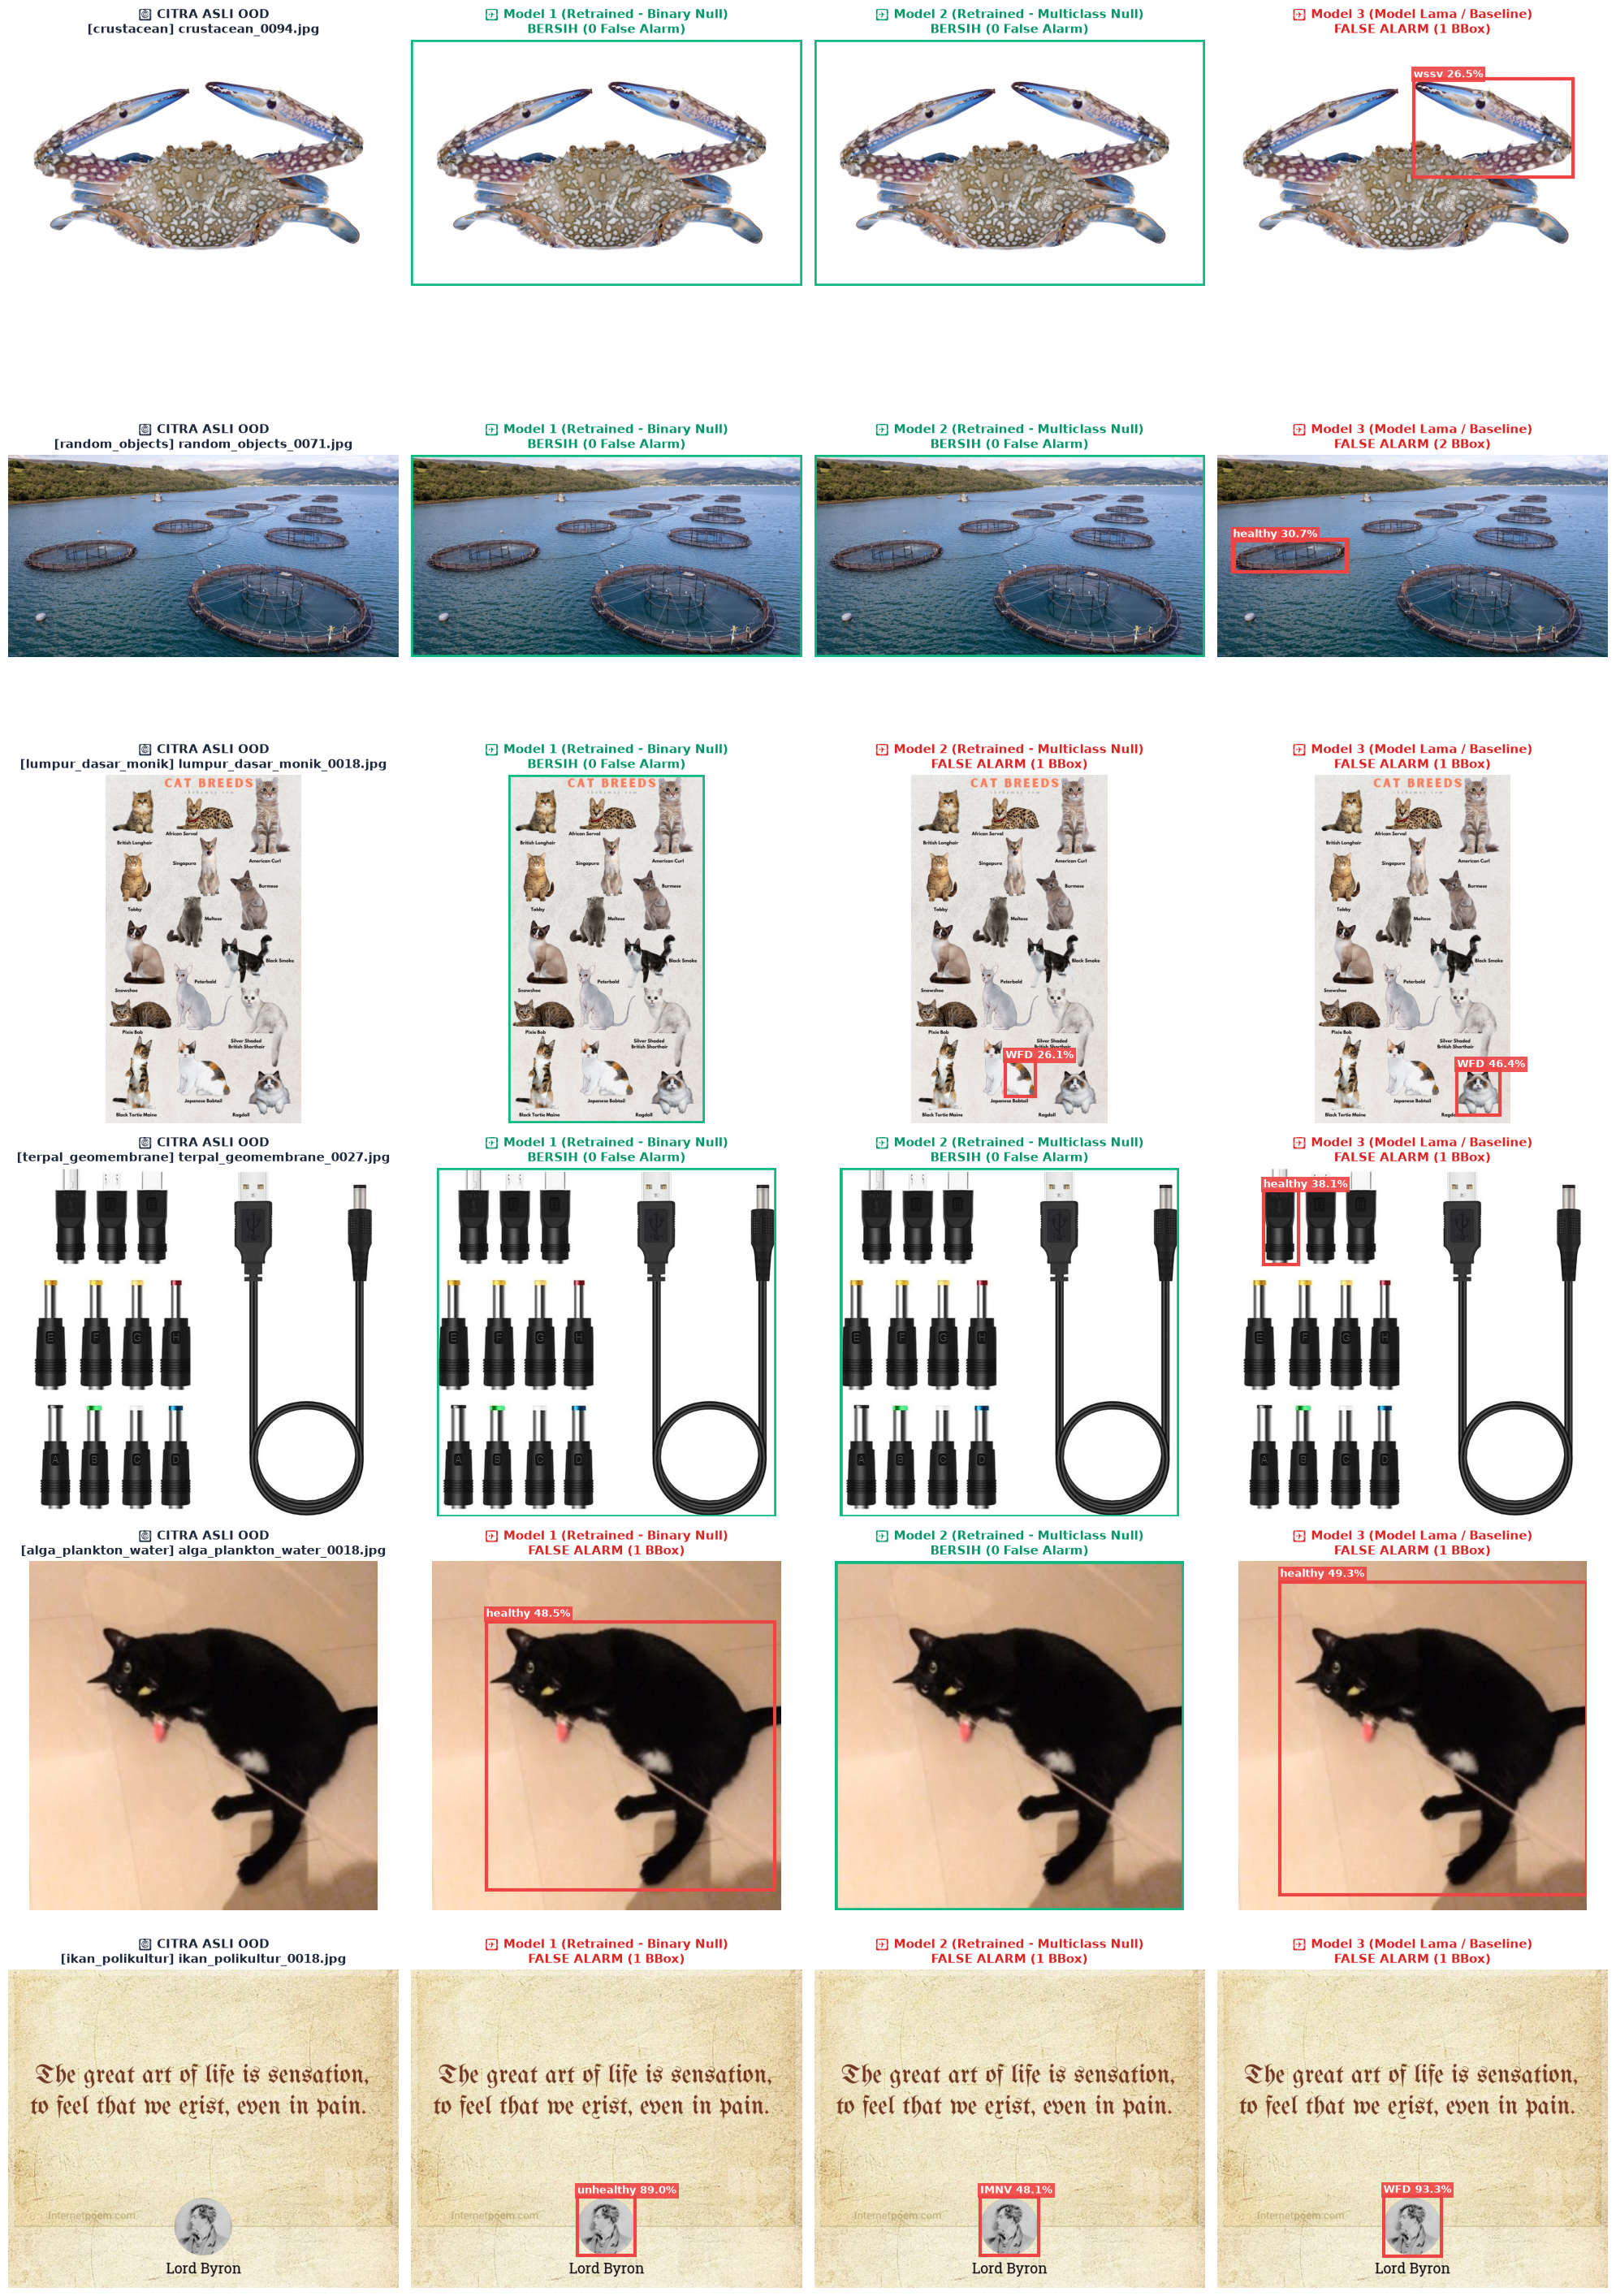

In [10]:
# Memilih citra-citra representatif di mana Model 3 mengalami False Alarm
m3_eval_dets = model_metrics["m3"]["eval_dets"]

# Kelompokkan citra false alarm Model 3 per kategori unik
m3_fp_by_cat = {}
for d in m3_eval_dets:
    c = d["category"]
    if c not in m3_fp_by_cat:
        m3_fp_by_cat[c] = []
    m3_fp_by_cat[c].append(d["path"])

# Pilih hingga 6 sampel gambar dari kategori yang berbeda
selected_test_paths = []
for c, paths in m3_fp_by_cat.items():
    if len(selected_test_paths) < 6:
        selected_test_paths.append(paths[0])

# Jika kurang dari 6, lengkapi dari gambar acak yang tersedia
if len(selected_test_paths) < 6:
    for d in m3_eval_dets:
        if d["path"] not in selected_test_paths:
            selected_test_paths.append(d["path"])
        if len(selected_test_paths) >= 6:
            break

# Jika masih kosong (misal model 3 sangat sempurna), ambil sampel OOD acak
if len(selected_test_paths) == 0:
    selected_test_paths = list(df_images["path"].sample(min(4, len(df_images)), random_state=42))

num_samples = len(selected_test_paths)
print(f"📸 Menampilkan Komparasi Visual Side-by-Side pada {num_samples} Kasus Uji:")

fig, axes = plt.subplots(num_samples, 4, figsize=(20, 4.8 * num_samples))
if num_samples == 1:
    axes = np.array([axes])

for row_idx, img_p in enumerate(selected_test_paths):
    orig_img = Image.open(img_p).convert("RGB")
    cat_name = Path(img_p).parent.name
    fname = Path(img_p).name
    
    # 1. Kolom 1: Citra Asli OOD
    ax_orig = axes[row_idx, 0]
    ax_orig.imshow(orig_img)
    ax_orig.set_title(f"📷 CITRA ASLI OOD\n[{cat_name}] {fname}", fontsize=11, fontweight="bold", color="#1e293b")
    ax_orig.axis("off")
    
    # 2. Kolom 2, 3, 4: Model 1, Model 2, Model 3
    for col_idx, m_cfg in enumerate(MODELS_CONFIG, start=1):
        ax = axes[row_idx, col_idx]
        ax.imshow(orig_img)
        
        m_key = m_cfg["key"]
        # Ambil deteksi gambar ini untuk model terkait (pada EVAL_CONF_THRESHOLD)
        img_dets = [d for d in model_metrics[m_key]["eval_dets"] if d["path"] == img_p]
        
        if len(img_dets) == 0:
            # Model BERSIH (Sukses menolak OOD)
            ax.set_title(f"✅ {m_cfg['label']}\nBERSIH (0 False Alarm)", 
                         fontsize=11, fontweight="bold", color="#059669")
            # Beri frame hijau tipis
            rect_frame = patches.Rectangle((0, 0), orig_img.width, orig_img.height, 
                                           linewidth=4, edgecolor="#10b981", facecolor="none")
            ax.add_patch(rect_frame)
        else:
            # Model GAGAL (False Alarm)
            max_c = max(d["conf"] for d in img_dets)
            top_cls = img_dets[0]["class"]
            ax.set_title(f"❌ {m_cfg['label']}\nFALSE ALARM ({len(img_dets)} BBox)", 
                         fontsize=11, fontweight="bold", color="#dc2626")
            
            # Gambar setiap Bounding Box Palsu
            for d in img_dets:
                x1, y1, x2, y2 = d["box"]
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                                         linewidth=3, edgecolor="#ef4444", facecolor="none")
                ax.add_patch(rect)
                ax.text(
                    x1, max(0, y1 - 6),
                    f"{d['class']} {d['conf']*100:.1f}%",
                    color="white",
                    fontsize=9.5,
                    fontweight="bold",
                    bbox=dict(facecolor="#ef4444", edgecolor="none", pad=2, alpha=0.9)
                )
        ax.axis("off")

plt.tight_layout()
plt.show()


## Section 7: Ekspor Hasil Laporan Benchmark
Menyimpan ringkasan komparasi ke file CSV di folder `reports/` untuk dilampirkan ke dokumen laporan penelitian atau presentasi.


In [11]:
# Buat folder laporan jika belum ada
os.makedirs("reports", exist_ok=True)

# 1. Ekspor Tabel Komparasi per Kategori
csv_cat_path = "reports/ood_benchmark_3models_comparison.csv"
df_cat_display.to_csv(csv_cat_path, index=False)

# 2. Ekspor Rekomendasi Threshold Operasional
csv_thresh_path = "reports/ood_operational_threshold_recommendations.csv"
df_deploy.to_csv(csv_thresh_path, index=False)

# 3. Ekspor Data Sweep Threshold
csv_sweep_path = "reports/ood_threshold_sweep_data.csv"
df_sweep.to_csv(csv_sweep_path, index=False)

print("=" * 80)
print("💾 BERKAS LAPORAN BERHASIL DISIMPAN:")
print("=" * 80)
print(f"1. Tabel Komparasi Kategori  : {csv_cat_path}")
print(f"2. Panduan Threshold App     : {csv_thresh_path}")
print(f"3. Data Sweep Threshold       : {csv_sweep_path}")
print("=" * 80)


💾 BERKAS LAPORAN BERHASIL DISIMPAN:
1. Tabel Komparasi Kategori  : reports/ood_benchmark_3models_comparison.csv
2. Panduan Threshold App     : reports/ood_operational_threshold_recommendations.csv
3. Data Sweep Threshold       : reports/ood_threshold_sweep_data.csv
